[i] ROOT = /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025
[i] Looking for .set under: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs
[i] Groups detected: ['AD', 'CN', 'FTD']
[i] Found 88 subject folders
[i] Using mne-connectivity.spectral_connectivity_epochs
[ok] sub-001 (AD): global alpha wPLI = 0.0948  -> sub-001_alpha_wpli.npy
[ok] sub-002 (AD): global alpha wPLI = 0.1335  -> sub-002_alpha_wpli.npy
[ok] sub-003 (AD): global alpha wPLI = 0.1348  -> sub-003_alpha_wpli.npy
[ok] sub-004 (AD): global alpha wPLI = 0.0382  -> sub-004_alpha_wpli.npy
[ok] sub-005 (AD): global alpha wPLI = 0.1157  -> sub-005_alpha_wpli.npy
[ok] sub-006 (AD): global alpha wPLI = 0.2081  -> sub-006_alpha_wpli.npy
[ok] sub-007 (AD): global alpha wPLI = 0.0878  -> sub-007_alpha_wpli.npy
[ok] sub-008 (AD): global alpha wPLI = 0.0664  -> sub-008_alpha_wpli.npy
[ok] sub-009 (AD): global alpha wPLI = 0.1701  -> sub-009_alpha_wpli.npy
[ok] sub-010 (AD): global alpha wPLI = 0.1

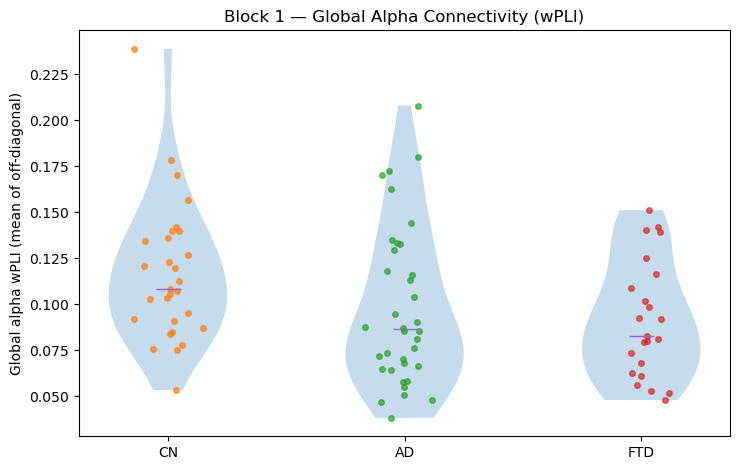

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block1/block1_global_alpha_violin.png


In [10]:
# === Block 1: Global Alpha Connectivity (wPLI) ===

from pathlib import Path
import warnings, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------- 0) Paths (EDIT ROOT ONLY) ----------
# Define root directory
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")

# Define existing folders
OUTS = ROOT / "outputs"             # contains sub-xxx folders with *_cleaned_final.set
PARTIC = ROOT / "participants.tsv"  # has participant_id and Group/A/F/C

# Define save directory: outputs/connectivity/block1
SAVE_DIR = OUTS / "connectivity" / "block1"
SAVE_DIR.mkdir(exist_ok=True, parents=True)

print(f"[i] ROOT = {ROOT}")
print(f"[i] Looking for .set under: {OUTS}")

# ---------- 1) Participants (case-insensitive columns) ----------
if not PARTIC.exists():
    raise FileNotFoundError(f"participants.tsv not found at: {PARTIC}")

dfp = pd.read_csv(PARTIC, sep="\t")
cols = {c.lower(): c for c in dfp.columns}
PID_COL   = cols.get("participant_id", "participant_id")
GROUP_COL = cols.get("group", "Group")  # handles 'Group' or 'group'

# Clean subject ids: 'sub-001' -> '001'
sid = (dfp[PID_COL].astype(str)
       .str.strip()
       .str.replace(r"^sub-", "", regex=True))

def canon_group(x: str) -> str:
    s = str(x).strip().upper()
    return {"C":"CN","A":"AD","F":"FTD"}.get(s, s)

grp = dfp[GROUP_COL].map(canon_group)
group_map = dict(zip(sid, grp))
print(f"[i] Groups detected: {sorted(set(grp))}")

# ---------- 2) Util: find subject .set files ----------
def find_clean_set(sub_dir: Path) -> Path | None:
    # Prefer *_cleaned_final.set; fall back to any .set
    candidates = sorted(sub_dir.glob("*_cleaned_final.set"))
    if not candidates:
        candidates = sorted(sub_dir.glob("*.set"))
    return candidates[0] if candidates else None

subs = sorted([p for p in OUTS.glob("sub-*") if p.is_dir()])
print(f"[i] Found {len(subs)} subject folders")

# ---------- 3) Connectivity backend (MNE built-in or mne-connectivity) ----------
USE_MNE_CONNECTIVITY = False
try:
    # Newer MNE has mne.connectivity.spectral_connectivity, but we try both paths safely
    from mne_connectivity import spectral_connectivity_epochs as conn_epochs
    USE_MNE_CONNECTIVITY = True
    print("[i] Using mne-connectivity.spectral_connectivity_epochs")
except Exception:
    try:
        from mne.connectivity import spectral_connectivity
        conn_epochs = None  # we'll call spectral_connectivity with epochs data
        print("[i] Using mne.connectivity.spectral_connectivity")
    except Exception as e:
        raise ImportError(
            "No connectivity function available. Install one of:\n"
            "  pip install mne-connectivity\n"
            "or update MNE to include mne.connectivity.spectral_connectivity\n"
            f"Original error: {e}"
        )

# ---------- 4) Parameters ----------
BAND = "alpha"
FMIN, FMAX = 8.0, 13.0
EPOCH_LEN = 2.0   # seconds, non-overlapping
METHOD = "wpli"   # 'wpli' widely available; 'wpli2_debiased' if your version supports it
MONTAGE_NAME = "standard_1020"

# Legacy label normalization if present
RENAME_MAP = {"T3":"T7", "T4":"T8", "T5":"P7", "T6":"P8"}

# ---------- 5) Per-subject processing ----------
def subject_global_alpha_wpli(set_path: Path) -> tuple[float, np.ndarray, list[str]]:
    """Load .set, epoch, compute alpha wPLI matrix, return (scalar, matrix, ch_names)."""
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose='ERROR')

    # Drop non-EEG channels if any
    picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, misc=False, stim=False)
    raw.pick(picks_eeg)

    # Optional: rename legacy labels only if present
    present = {old:new for old,new in RENAME_MAP.items() if old in raw.ch_names}
    if present:
        raw.rename_channels(present)

    # Montage for 10–20 positions (best-effort)
    try:
        raw.set_montage(MONTAGE_NAME, match_case=False)
    except Exception:
        pass

    # Band-limit to alpha (we are NOT re-cleaning; this is just to isolate the band of interest)
    raw_alpha = raw.copy().filter(FMIN, FMAX, fir_design="firwin", phase="zero", verbose='ERROR')

    # Epoch into fixed-length, non-overlapping chunks
    events = mne.make_fixed_length_events(raw_alpha, id=1, duration=EPOCH_LEN, overlap=0.0)
    epochs = mne.Epochs(raw_alpha, events, tmin=0.0, tmax=EPOCH_LEN, baseline=None,
                        reject_by_annotation=True, preload=True, verbose='ERROR')

    if len(epochs) < 5:
        raise RuntimeError(f"Too few clean {EPOCH_LEN}s epochs ({len(epochs)}) in {set_path.name}")

    ch_names = epochs.ch_names
    data = epochs.get_data()  # (n_epochs, n_channels, n_times)

    # Compute wPLI in alpha
    if USE_MNE_CONNECTIVITY:
        con = conn_epochs(
            epochs,
            method=METHOD,
            mode="fourier",
            fmin=FMIN, fmax=FMAX,
            tmin=0.0, tmax=EPOCH_LEN,
            n_jobs=1, verbose='ERROR'
        )
        # mne-connectivity returns an object; get array with shape (n_nodes, n_nodes, n_freqs)
        w = con.get_data(output="dense")  # (n_nodes, n_nodes, n_freqs)
        if w.ndim == 3 and w.shape[-1] >= 1:
            W = np.nanmean(w, axis=-1)  # average across freq bins inside alpha
        else:
            W = w
    else:
        # Older API: returns (conn, freqs, times, n_epochs, n_tapers)
        conn, freqs, _, _, _ = spectral_connectivity(
            data,
            method=METHOD,
            mode="fourier",
            sfreq=raw.info["sfreq"],
            fmin=FMIN, fmax=FMAX,
            faverage=True,   # average across alpha band
            mt_adaptive=False, n_jobs=1, verbose='ERROR'
        )
        # conn shape: (n_connections, n_freqs) with faverage=True -> (n_connections, 1)
        n_ch = len(ch_names)
        W = np.zeros((n_ch, n_ch), dtype=float)
        # fill upper-tri from conn vector
        idx = 0
        for i in range(n_ch):
            for j in range(i+1, n_ch):
                W[i, j] = conn[idx, 0]
                W[j, i] = conn[idx, 0]
                idx += 1

    # Global score: mean of off-diagonal
    off_diag = W[~np.eye(W.shape[0], dtype=bool)]
    score = float(np.nanmean(off_diag))
    return score, W, ch_names

# ---------- 6) Run all subjects ----------
rows = []
failed = []
for sub_dir in subs:
    sub_id_full = sub_dir.name  # 'sub-001'
    sub_id = sub_id_full.replace("sub-", "")
    set_path = find_clean_set(sub_dir)

    if set_path is None:
        print(f"[warn] No .set in {sub_dir}")
        failed.append((sub_id, "no_set"))
        continue

    group = group_map.get(sub_id, "UNKNOWN")
    try:
        score, W, chn = subject_global_alpha_wpli(set_path)
        # Save matrix
        npy_path = SAVE_DIR / f"{sub_id_full}_{BAND}_wpli.npy"
        np.save(npy_path, W)

        rows.append({
            "subject": sub_id_full,
            "group": group,
            "band": BAND,
            "global_wpli": score,
            "n_channels": len(chn),
            "n_edges": int((len(chn)* (len(chn)-1)) / 2)
        })
        print(f"[ok] {sub_id_full} ({group}): global {BAND} wPLI = {score:.4f}  -> {npy_path.name}")
    except Exception as e:
        print(f"[fail] {sub_id_full} ({group}): {e}")
        failed.append((sub_id, str(e)))

# Save scores CSV + failures JSON
df_scores = pd.DataFrame(rows)
csv_path = SAVE_DIR / "global_alpha_wpli_scores.csv"
df_scores.to_csv(csv_path, index=False)
print(f"[i] Wrote: {csv_path}  (n={len(df_scores)})")

if failed:
    with open(SAVE_DIR / "failures.json", "w") as f:
        json.dump(failed, f, indent=2)
    print(f"[i] Some subjects failed ({len(failed)}). See failures.json")

# ---------- 7) Plot violin + swarm ----------
if len(df_scores):
    order = ["CN", "AD", "FTD"]
    df_scores["group"] = pd.Categorical(df_scores["group"], categories=order, ordered=True)
    df_scores = df_scores.sort_values("group")

    plt.figure(figsize=(7.5, 4.8))
    # violin by group (matplotlib vanilla)
    groups = [g for g in order if g in set(df_scores["group"])]
    data = [df_scores.loc[df_scores["group"]==g, "global_wpli"].values for g in groups]

    parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.25)

    # add swarm (jittered scatter)
    for i, vals in enumerate(data, start=1):
        if len(vals)==0: continue
        x = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.plot(x, vals, 'o', markersize=4, alpha=0.7)

    # add group medians
    medians = [np.median(v) if len(v) else np.nan for v in data]
    plt.plot(range(1, len(groups)+1), medians, marker="_", linestyle="none", markersize=18)

    plt.xticks(range(1, len(groups)+1), groups)
    plt.ylabel("Global alpha wPLI (mean of off-diagonal)")
    plt.title("Block 1 — Global Alpha Connectivity (wPLI)")
    plt.tight_layout()
    fig_path = SAVE_DIR / "block1_global_alpha_violin.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print(f"[i] Figure saved: {fig_path}")
else:
    print("[i] No scores to plot.")


[Classical ANOVA]
    Source        SS  DF        MS         F     p-unc       np2
0   group  0.009188   2  0.004594  3.059392  0.052116  0.067152
1  Within  0.127643  85  0.001502       NaN       NaN       NaN

[Pairwise comparisons]
   Contrast   A    B  Paired  Parametric         T        dof alternative  \
0    group  CN   AD   False        True  1.820983  62.514857   two-sided   
1    group  CN  FTD   False        True  2.596268  49.797863   two-sided   
2    group  AD  FTD   False        True  0.693095  55.714999   two-sided   

      p-unc    p-corr p-adjust   BF10     cohen  
0  0.073396  0.220187     bonf  1.023  0.447912  
1  0.012354  0.037062     bonf  4.087  0.710476  
2  0.491129  1.000000     bonf  0.329  0.173156  

Descriptive stats:
            mean       std  count
group                           
CN     0.116670  0.037845     29
AD     0.098355  0.043172     36
FTD    0.091569  0.031842     23


/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_48761/696144496.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("group")["global_wpli"].agg(["mean", "std", "count"])


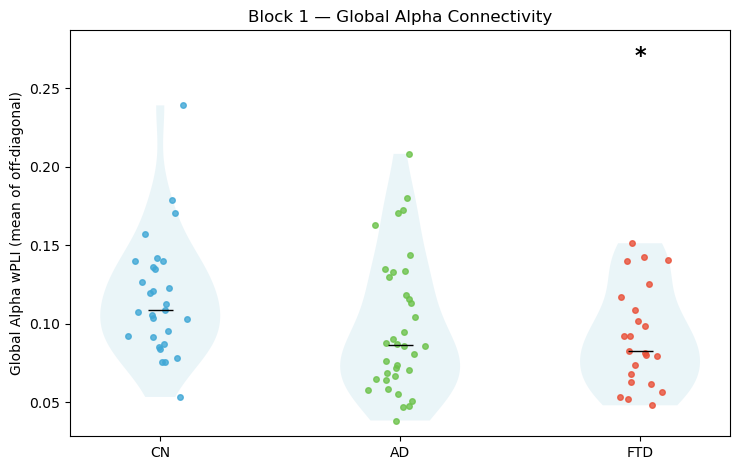

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_global_alpha_stats_violin.png
[i] ANOVA: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_global_alpha_ANOVA.csv
[i] Pairwise: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_global_alpha_pairwise.csv


In [19]:
# =====================================================
# Block 1: Group Statistics — Global Alpha Connectivity
# =====================================================
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ---------- Paths ----------
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block1"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- ANOVA ----------
anova_res = pg.anova(data=df, dv="global_wpli", between="group", detailed=True)
anova_path = SAVE_DIR / "block1_global_alpha_ANOVA.csv"
anova_res.to_csv(anova_path, index=False)
print("\n[Classical ANOVA]\n", anova_res)

# ---------- Pairwise t-tests ----------
pairwise = pg.pairwise_tests(
    data=df, dv="global_wpli", between="group",
    padjust="bonf", effsize="cohen"
)
pairwise_path = SAVE_DIR / "block1_global_alpha_pairwise.csv"
pairwise.to_csv(pairwise_path, index=False)
print("\n[Pairwise comparisons]\n", pairwise)

# ---------- Summary ----------
summary = df.groupby("group")["global_wpli"].agg(["mean", "std", "count"])
print("\nDescriptive stats:\n", summary)

# ---------- Derive significance vs CN ----------
sig_results = []
for _, row in pairwise.iterrows():
    if "CN" in (row["A"], row["B"]) and row["p-corr"] < 0.05:
        g1, g2 = row["A"], row["B"]
        if g1 != "CN":  # ensure CN first
            g1, g2 = g2, g1
        sig_results.append((g2, row["p-corr"]))

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# ---------- Visualization ----------
order = ["CN", "AD", "FTD"]
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)
df = df.sort_values("group")

plt.figure(figsize=(7.5, 4.8))
groups = [g for g in order if g in set(df["group"])]
data = [df.loc[df["group"] == g, "global_wpli"].values for g in groups]

# Violin (light blue)
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("lightblue")
    pc.set_alpha(0.25)

# Scatter dots per group
dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN blue, AD green, FTD red
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    if len(vals) == 0:
        continue
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

# Group medians
medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
         color="black", markersize=18)

plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Global Alpha wPLI (mean of off-diagonal)")
plt.title("Block 1 — Global Alpha Connectivity")

# ---------- Significance stars ----------
ymax = max([np.max(v) for v in data if len(v) > 0])
offset = ymax * 0.1
for group, p in sig_results:
    star = p_to_star(p)
    if star:
        idx = order.index(group) + 1
        plt.text(idx, ymax + offset, star,
                 ha="center", va="bottom", fontsize=16,
                 color="black", fontweight="bold")

plt.ylim(None, ymax + offset * 2)
plt.tight_layout()

# ---------- Save ----------
fig_path = SAVE_DIR / "block1_global_alpha_stats_violin.png"
plt.savefig(fig_path, dpi=160)
plt.show()

print(f"[i] Figure saved: {fig_path}")
print(f"[i] ANOVA: {anova_path}")
print(f"[i] Pairwise: {pairwise_path}")






[i] Loaded 88 entries from global_alpha_wpli_scores.csv
   subject group   band  global_wpli  n_channels  n_edges
0  sub-001    AD  alpha     0.094776          19      171
1  sub-002    AD  alpha     0.133480          19      171
2  sub-003    AD  alpha     0.134774          19      171
[Permutation ANOVA] Observed F = 3.059, p_perm = 0.0500


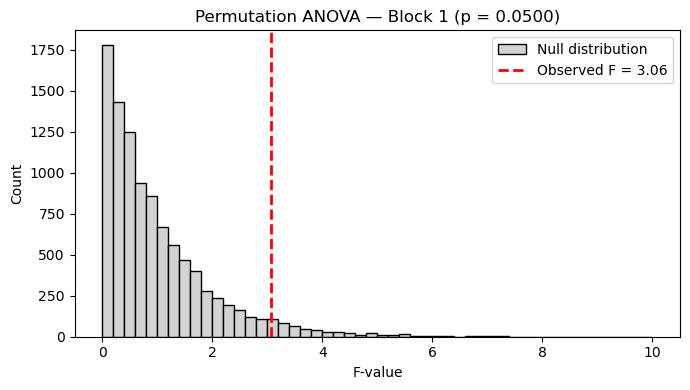

[i] Permutation histogram saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_permutation_ANOVA_hist.png
[i] Summary text → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_permutation_summary.txt


In [9]:
# =====================================================
# Block 1 — Permutation ANOVA (nonparametric validation)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pingouin import anova
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "block1" / "global_alpha_wpli_scores.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block1"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(IN_CSV)
df.rename(columns={"group": "group", "global_wpli": "global_wpli"}, inplace=True)
print(f"[i] Loaded {len(df)} entries from {IN_CSV.name}")
print(df.head(3))

# ---------- Permutation Function ----------
def perm_anova(df, n_perm=10000, seed=42):
    np.random.seed(seed)
    real_F = anova(data=df, dv="global_wpli", between="group", detailed=True)["F"].values[0]
    perm_F = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = df.copy()
        shuffled["group"] = np.random.permutation(shuffled["group"].values)
        perm_F[i] = anova(data=shuffled, dv="global_wpli", between="group", detailed=True)["F"].values[0]
    p_perm = np.mean(perm_F >= real_F)
    return real_F, p_perm, perm_F

# ---------- Run ----------
real_F, p_perm, perm_F = perm_anova(df, n_perm=10000)
print(f"[Permutation ANOVA] Observed F = {real_F:.3f}, p_perm = {p_perm:.4f}")

# ---------- Save ----------
np.save(SAVE_DIR / "block1_permutation_Fdist.npy", perm_F)
with open(SAVE_DIR / "block1_permutation_summary.txt", "w") as f:
    f.write(f"Observed F = {real_F:.3f}\n")
    f.write(f"Permutation p = {p_perm:.5f}\n")
    f.write(f"n_perm = {len(perm_F)}\n")

# ---------- Visualization ----------
plt.figure(figsize=(7, 4))
plt.hist(perm_F, bins=50, color="lightgray", edgecolor="black", label="Null distribution")
plt.axvline(real_F, color="red", linestyle="--", lw=2, label=f"Observed F = {real_F:.2f}")
plt.xlabel("F-value")
plt.ylabel("Count")
plt.title(f"Permutation ANOVA — Block 1 (p = {p_perm:.4f})")
plt.legend()
plt.tight_layout()
out_path = SAVE_DIR / "block1_permutation_ANOVA_hist.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[i] Permutation histogram saved → {out_path}")
print(f"[i] Summary text → {SAVE_DIR / 'block1_permutation_summary.txt'}")


In [21]:
# =====================================================
# Block 1 — Graph-Theoretic Metrics + 95 % CIs (v2 add-on)
# =====================================================
import networkx as nx
import pingouin as pg
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
WPLI_DIR = ROOT / "outputs" / "connectivity" / "block1"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block1"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load main scores ----------
df = pd.read_csv(WPLI_DIR / "global_alpha_wpli_scores.csv")
print(f"[i] Loaded {len(df)} subjects for graph metrics")

# ---------- 1) Compute graph metrics per subject ----------
records = []
for _, row in df.iterrows():
    sid = row["subject"]
    npy_path = WPLI_DIR / f"{sid}_alpha_wpli.npy"
    if not npy_path.exists():
        print(f"[warn] Missing matrix for {sid}")
        continue
    W = np.load(npy_path)
    np.fill_diagonal(W, 0)
    G = nx.from_numpy_array(W)
    rec = {
        "subject": sid,
        "group": row["group"],
        "mean_degree": np.mean([d for _, d in G.degree(weight="weight")]),
        "global_eff": nx.global_efficiency(G),
        "clust_coeff": np.mean(list(nx.clustering(G, weight="weight").values()))
    }
    records.append(rec)

df_graph = pd.DataFrame(records)
graph_csv = SAVE_DIR / "block1_graph_metrics.csv"
df_graph.to_csv(graph_csv, index=False)
print(f"[i] Saved per-subject graph metrics → {graph_csv}")

# ---------- 2) ANOVA + pairwise for each graph metric ----------
for metric in ["mean_degree", "global_eff", "clust_coeff"]:
    aov = pg.anova(
        data=df_graph,
        dv=metric,
        between="group",
        detailed=True
    )

    pair = pg.pairwise_tests(
        data=df_graph,     # FIXED
        dv=metric,
        between="group",
        padjust="bonf",
        effsize="cohen"
    )

    aov.to_csv(SAVE_DIR / f"block1_{metric}_anova.csv", index=False)
    pair.to_csv(SAVE_DIR / f"block1_{metric}_pairwise.csv", index=False)

    print(f"[i] {metric}: ANOVA & pairwise tables saved")


# ---------- 3) 95 % bootstrap confidence intervals ----------
boot_n = 10000
# CI for group means (for figure captions)
ci_means = df.groupby("group")["global_wpli"].apply(
    lambda x: pg.compute_bootci(x, func="mean", n_boot=boot_n, seed=42)
)
ci_means.to_csv(SAVE_DIR / "block1_CI_means.csv")
print("[i] Saved 95 % CI for group means")

# CI for each pairwise Cohen's d
def boot_ci_d(x1, x2, n_boot=boot_n):
    return pg.compute_bootci(x1, func=lambda v: pg.compute_effsize(v, x2, eftype="cohen"),
                             n_boot=n_boot, seed=42)

pairs = [("CN","AD"), ("CN","FTD"), ("AD","FTD")]
ci_d = []
for g1, g2 in pairs:
    x1 = df.loc[df["group"]==g1, "global_wpli"]
    x2 = df.loc[df["group"]==g2, "global_wpli"]
    ci = boot_ci_d(x1, x2)
    ci_d.append({"contrast": f"{g1}-{g2}", "CI_low": ci[0], "CI_high": ci[1]})
ci_d_df = pd.DataFrame(ci_d)
ci_d_path = SAVE_DIR / "block1_CI_d.csv"
ci_d_df.to_csv(ci_d_path, index=False)
print(f"[i] Saved 95 % CI for effect sizes → {ci_d_path}")

print("[✓] Graph metrics + CI computation complete.")

[i] Loaded 88 subjects for graph metrics
[i] Saved per-subject graph metrics → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_graph_metrics.csv
[i] mean_degree: ANOVA & pairwise tables saved
[i] global_eff: ANOVA & pairwise tables saved
[i] clust_coeff: ANOVA & pairwise tables saved
[i] Saved 95 % CI for group means
[i] Saved 95 % CI for effect sizes → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_CI_d.csv
[✓] Graph metrics + CI computation complete.


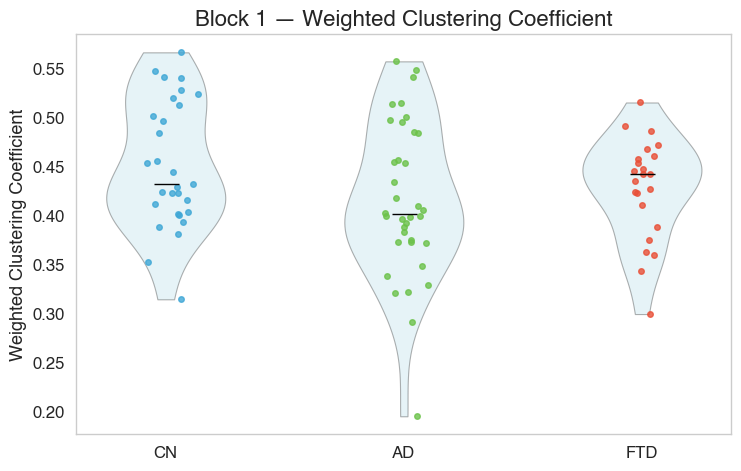

[✓] Figure saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block1/block1_clust_coeff_violin_match.png


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
STATS_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block1"

df_graph = pd.read_csv(STATS_DIR / "block1_graph_metrics.csv")

order = ["CN", "AD", "FTD"]
df_graph["group"] = pd.Categorical(df_graph["group"], categories=order, ordered=True)
df_graph = df_graph.sort_values("group")

# --- violin data
groups = [g for g in order if g in set(df_graph["group"])]
data = [df_graph.loc[df_graph["group"] == g, "clust_coeff"].values for g in groups]

plt.figure(figsize=(7.5, 4.8))
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)

# --- styling: soft fill like before
for pc in parts["bodies"]:
    pc.set_facecolor("lightblue")
    pc.set_edgecolor("black")
    pc.set_alpha(0.3)

# --- scatter dots (same as before)
dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN, AD, FTD colors
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    if len(vals) == 0:
        continue
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

# --- medians
medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
         color="black", markersize=18)

plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Weighted Clustering Coefficient")
plt.title("Block 1 — Weighted Clustering Coefficient")

plt.grid(False)
plt.tight_layout()
out_path = STATS_DIR / "block1_clust_coeff_violin_match.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"[✓] Figure saved → {out_path}")



